In [14]:
# Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from arch import arch_model
from scipy.stats import norm

In [15]:

def bsm_price(S, K, T, r, q, sigma, option_type="call"):
    if np.any(T <= 0):
        intrinsic = np.where(
            option_type == "call",
            np.maximum(S - K, 0),
            np.maximum(K - S, 0)
        )
        return intrinsic

    d1 = (np.log(S/K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        price = (S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2))
    else:
        price = (K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1))

    return price

def _d1_d2(S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

def delta(S, K, T, r, q, sigma, option_type="call"):
    d1, d2 = _d1_d2(S, K, T, r, q, sigma)
    if option_type == "call":
        return np.exp(-q * T) * norm.cdf(d1)
    else:
        return np.exp(-q * T) * (norm.cdf(d1) - 1)


In [16]:
# Pull 20 years of SPY daily data
spy = yf.download("SPY", start="2004-01-01", end="2024-12-31", auto_adjust=True, progress=False)

# Keep only closing prices
prices = spy["Close"].dropna()

# Compute log returns
returns = np.log(prices / prices.shift(1)).dropna()

print(f"Date range:   {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"Trading days: {len(prices)}")
print(f"Return stats:")
print(returns.describe().round(4))

Date range:   2004-01-02 → 2024-12-30
Trading days: 5284
Return stats:
Ticker        SPY
count   5283.0000
mean       0.0004
std        0.0118
min       -0.1159
25%       -0.0039
50%        0.0007
75%        0.0058
max        0.1356


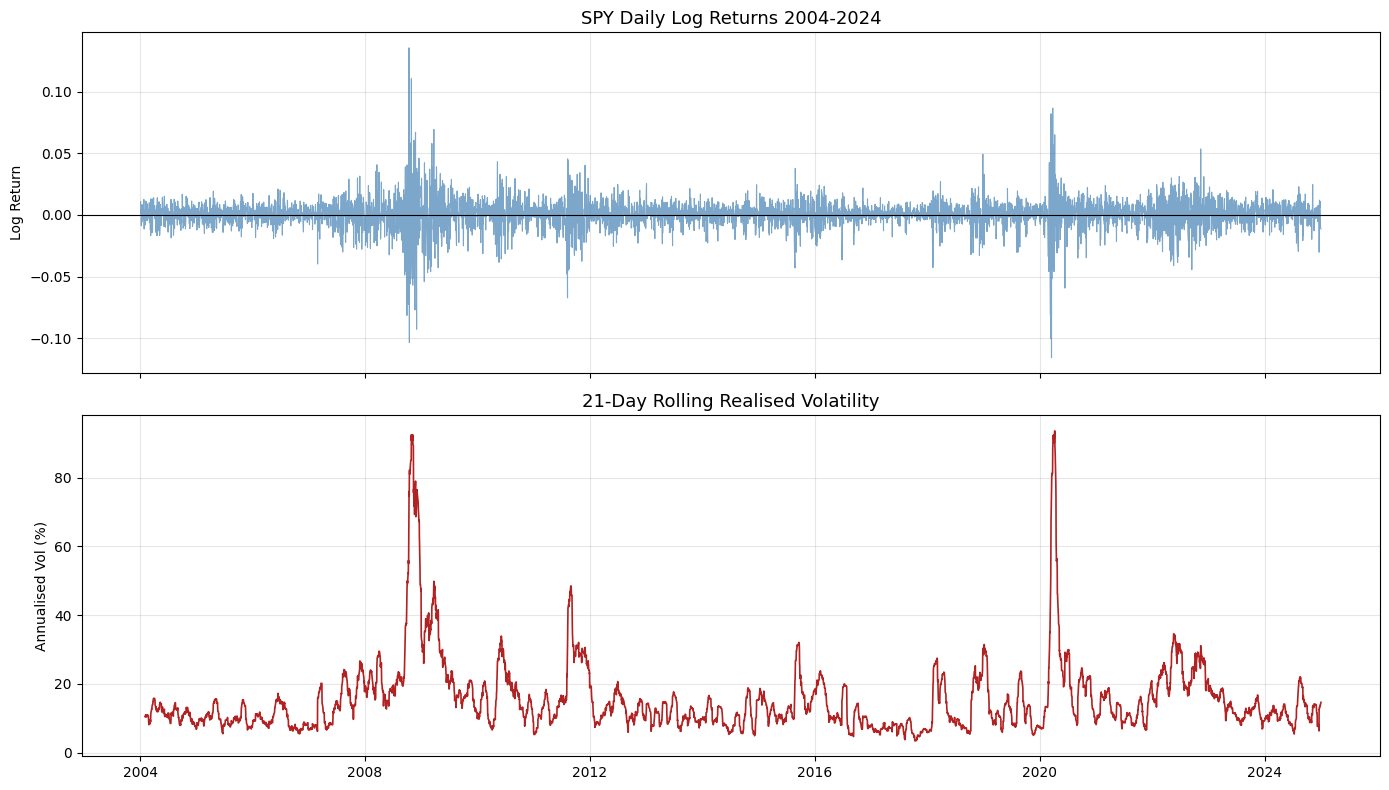

Rolling vol stats (annualised %):
Ticker      SPY
count   5263.00
mean      15.46
std       10.86
min        3.42
25%        9.25
50%       12.67
75%       18.10
max       93.67


In [17]:
# Rolling 21-day realised volatility (annualised)
rolling_vol = returns.rolling(window=21).std() * np.sqrt(252)

# Plot returns and rolling vol together
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(returns.index, returns, lw=0.8, color="steelblue", alpha=0.7)
ax1.axhline(0, color="black", lw=0.8)
ax1.set_ylabel("Log Return")
ax1.set_title("SPY Daily Log Returns 2004-2024", fontsize=13)
ax1.grid(alpha=0.3)

ax2.plot(rolling_vol.index, rolling_vol * 100, lw=1.2, color="firebrick")
ax2.set_ylabel("Annualised Vol (%)")
ax2.set_title("21-Day Rolling Realised Volatility", fontsize=13)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("returns_rolling_vol.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Rolling vol stats (annualised %):")
print((rolling_vol * 100).describe().round(2))

In [18]:
# GARCH(1,1) expects returns scaled to percentage — multiply by 100
returns_pct = returns * 100

# Fit GARCH(1,1) model
model = arch_model(returns_pct, vol="Garch", p=1, q=1, dist="normal")
result = model.fit(disp="off")   # disp="off" suppresses verbose output

print(result.summary())

omega    = 0.0283
alpha    = 0.1318
beta     = 0.8435

long_run_var     = omega / (1 - alpha - beta)
long_run_vol_pct = np.sqrt(long_run_var * 252)
print(f"Long-run annualised vol: {long_run_vol_pct:.2f}%")

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    SPY   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6930.42
Distribution:                  Normal   AIC:                           13868.8
Method:            Maximum Likelihood   BIC:                           13895.1
                                        No. Observations:                 5283
Date:                Sun, Apr 19 2026   Df Residuals:                     5282
Time:                        15:25:48   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0751  1.053e-02      7.130  1.007e-12 [5.

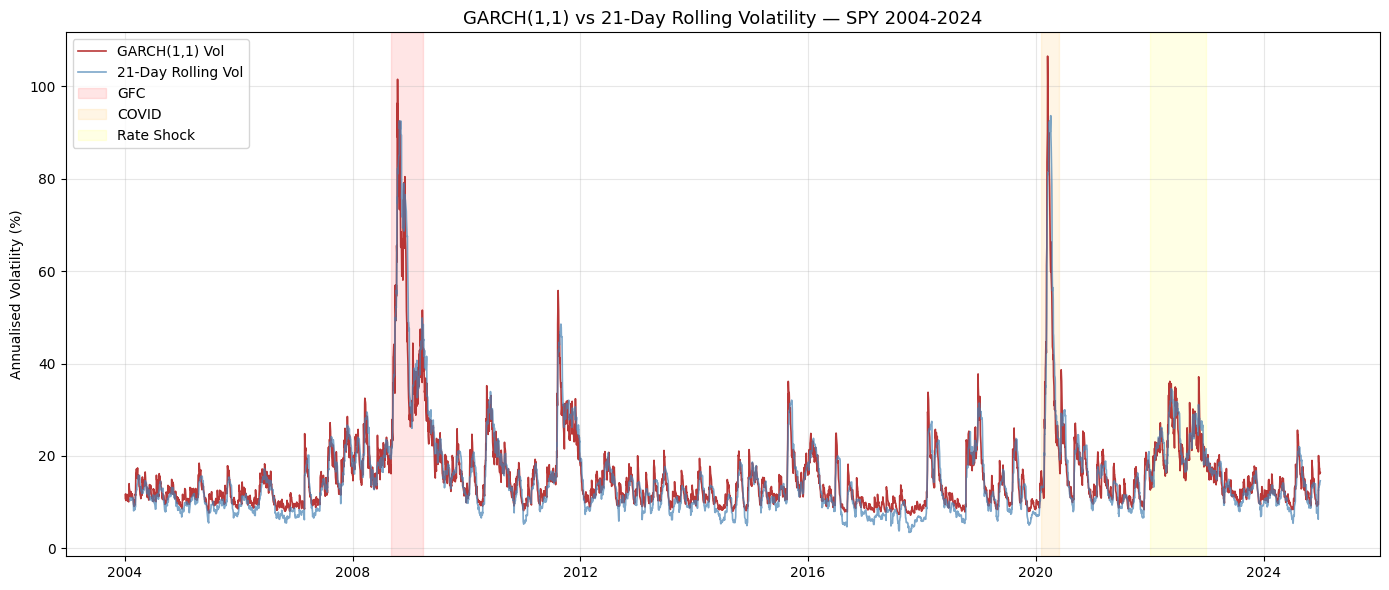

In [19]:
# Extract GARCH conditional volatility (annualised)
garch_vol = result.conditional_volatility * np.sqrt(252) / 100  # back to decimal

# Align rolling vol index with GARCH vol
rolling_vol_aligned = rolling_vol.reindex(garch_vol.index)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(garch_vol.index, garch_vol * 100, 
        lw=1.2, color="firebrick", label="GARCH(1,1) Vol", alpha=0.9)
ax.plot(rolling_vol_aligned.index, rolling_vol_aligned * 100, 
        lw=1.2, color="steelblue", label="21-Day Rolling Vol", alpha=0.7)

# Shade major stress regimes
ax.axvspan("2008-09-01", "2009-03-31", alpha=0.1, color="red", label="GFC")
ax.axvspan("2020-02-01", "2020-05-31", alpha=0.1, color="orange", label="COVID")
ax.axvspan("2022-01-01", "2022-12-31", alpha=0.1, color="yellow", label="Rate Shock")

ax.set_ylabel("Annualised Volatility (%)")
ax.set_title("GARCH(1,1) vs 21-Day Rolling Volatility — SPY 2004-2024", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("garch_vs_rolling.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# Build a clean aligned dataframe first
vol_df = pd.DataFrame({
    "prices":      prices_s,
    "returns":     returns_s,
    "rolling_vol": rolling_vol_s,
    "garch_vol":   garch_vol
}, index=prices_s.index).dropna()

print(f"Aligned dataframe shape: {vol_df.shape}")
print(vol_df.tail())

Aligned dataframe shape: (5263, 4)
                prices   returns  rolling_vol  garch_vol
Date                                                    
2024-12-23  586.186584  0.005970     0.132525   0.184739
2024-12-24  592.702148  0.011054     0.137460   0.174374
2024-12-26  592.741577  0.000067     0.137099   0.172880
2024-12-27  586.502075 -0.010582     0.141067   0.161057
2024-12-30  579.809082 -0.011477     0.146080   0.163890


In [24]:
def delta_hedge_simulation_v2(df, vol_col, r=0.05, q=0.013):
    hedging_errors = []
    T_initial = 0.25

    for i in range(1, len(df) - 1):
        S      = df["prices"].iloc[i]
        S_next = df["prices"].iloc[i + 1]
        sigma  = df[vol_col].iloc[i]

        if np.isnan(sigma) or sigma <= 0:
            continue

        K = S
        T = max(T_initial - i % 21 / 252, 1/252)

        V_today    = bsm_price(S,      K, T,         r, q, sigma, "call")
        V_tomorrow = bsm_price(S_next, K, T - 1/252, r, q, sigma, "call")

        d = delta(S, K, T, r, q, sigma, "call")

        option_pnl = V_tomorrow - V_today
        hedge_pnl  = -d * (S_next - S)
        error      = option_pnl + hedge_pnl
        hedging_errors.append(error)

    return pd.Series(hedging_errors)


errors_rolling = delta_hedge_simulation_v2(vol_df, "rolling_vol")
errors_garch   = delta_hedge_simulation_v2(vol_df, "garch_vol")

var_rolling = errors_rolling.var()
var_garch   = errors_garch.var()
reduction   = (1 - var_garch / var_rolling) * 100

print(f"Hedging Error Variance — Rolling Vol:  {var_rolling:.6f}")
print(f"Hedging Error Variance — GARCH Vol:    {var_garch:.6f}")
print(f"Variance Reduction:                    {reduction:.1f}%")

Hedging Error Variance — Rolling Vol:  0.019288
Hedging Error Variance — GARCH Vol:    0.015054
Variance Reduction:                    22.0%


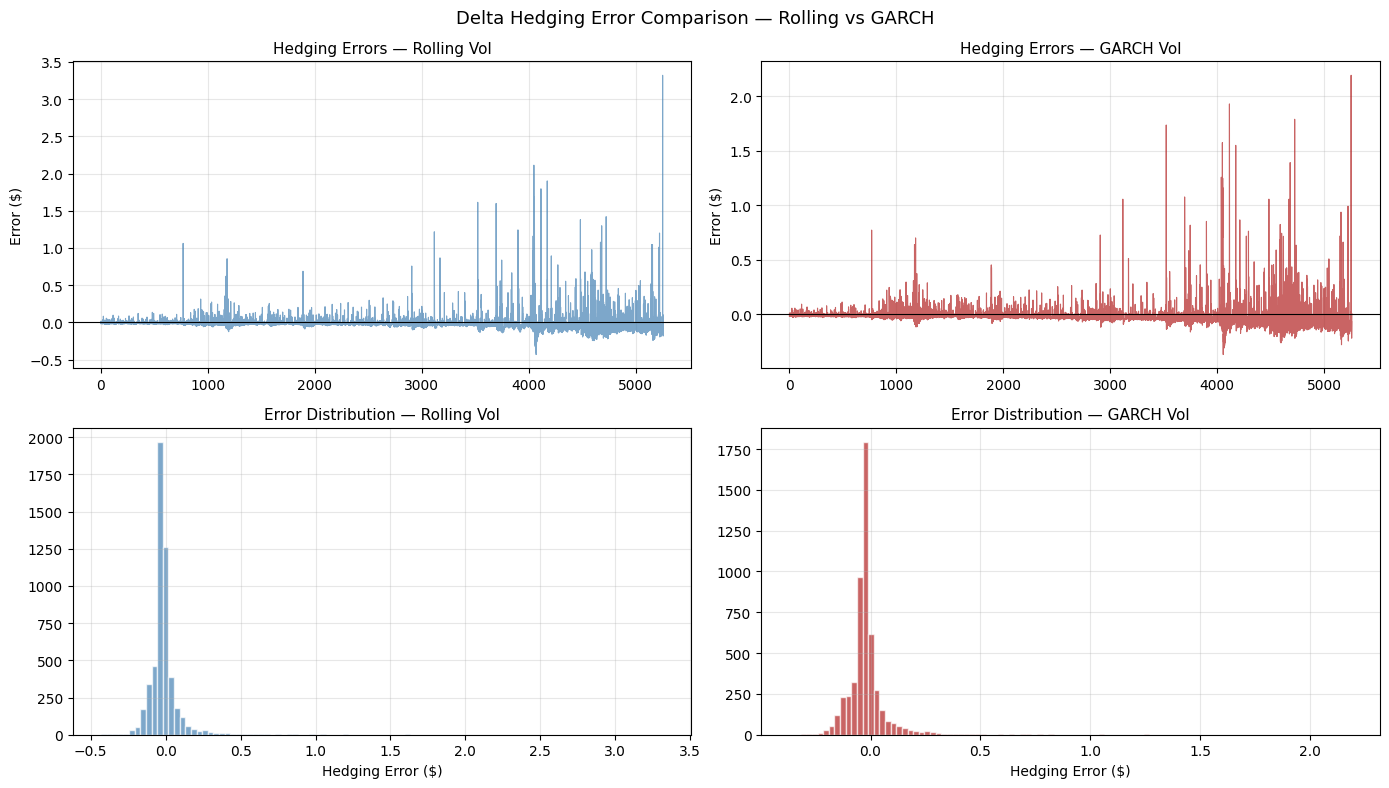

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Error time series
axes[0,0].plot(errors_rolling.values, lw=0.8, color="steelblue", alpha=0.7)
axes[0,0].set_title("Hedging Errors — Rolling Vol", fontsize=11)
axes[0,0].set_ylabel("Error ($)")
axes[0,0].axhline(0, color="black", lw=0.8)
axes[0,0].grid(alpha=0.3)

axes[0,1].plot(errors_garch.values, lw=0.8, color="firebrick", alpha=0.7)
axes[0,1].set_title("Hedging Errors — GARCH Vol", fontsize=11)
axes[0,1].set_ylabel("Error ($)")
axes[0,1].axhline(0, color="black", lw=0.8)
axes[0,1].grid(alpha=0.3)

# Error distributions
axes[1,0].hist(errors_rolling, bins=100, color="steelblue", 
               alpha=0.7, edgecolor="white")
axes[1,0].set_title("Error Distribution — Rolling Vol", fontsize=11)
axes[1,0].set_xlabel("Hedging Error ($)")
axes[1,0].grid(alpha=0.3)

axes[1,1].hist(errors_garch, bins=100, color="firebrick", 
               alpha=0.7, edgecolor="white")
axes[1,1].set_title("Error Distribution — GARCH Vol", fontsize=11)
axes[1,1].set_xlabel("Hedging Error ($)")
axes[1,1].grid(alpha=0.3)

plt.suptitle("Delta Hedging Error Comparison — Rolling vs GARCH", fontsize=13)
plt.tight_layout()
plt.savefig("hedging_errors.png", dpi=150, bbox_inches="tight")
plt.show()

Hedging Error Variance by Regime

Regime        Rolling Var    GARCH Var    Reduction     Days
----------------------------------------------------------
low              0.005128     0.003338        34.9%     2062
normal           0.021060     0.016432        22.0%     2353
stress           0.048438     0.038945        19.6%      846


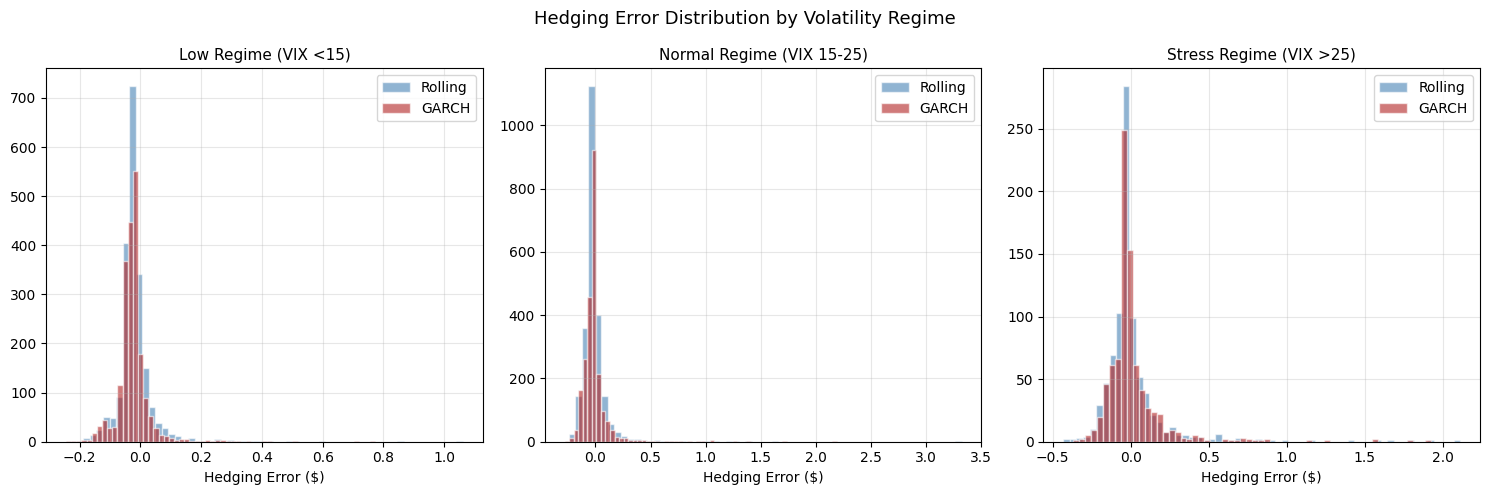

In [28]:
# ── Build regime labels using VIX as proxy ────────────────────────────────────
vix = yf.download("^VIX", start="2004-01-01", end="2024-12-31",
                  auto_adjust=True, progress=False)["Close"].squeeze()

# Align VIX with our vol dataframe
vix_aligned = vix.reindex(vol_df.index)

# Classify regimes
def classify_regime(vix_val):
    if vix_val < 15:
        return "low"
    elif vix_val <= 25:
        return "normal"
    else:
        return "stress"

regimes = vix_aligned.apply(classify_regime)

# ── Attach errors and regimes to aligned dataframe ───────────────────────────
# Trim errors to match vol_df length
n = min(len(errors_rolling), len(errors_garch), len(vol_df) - 2)

results_df = pd.DataFrame({
    "error_rolling": errors_rolling.values[:n],
    "error_garch":   errors_garch.values[:n],
    "regime":        regimes.values[1:n+1],
    "vix":           vix_aligned.values[1:n+1],
}, index=vol_df.index[1:n+1])

# ── Compute variance reduction per regime ─────────────────────────────────────
print("Hedging Error Variance by Regime\n")
print(f"{'Regime':<12} {'Rolling Var':>12} {'GARCH Var':>12} {'Reduction':>12} {'Days':>8}")
print("-" * 58)

for regime in ["low", "normal", "stress"]:
    mask = results_df["regime"] == regime
    var_r = results_df.loc[mask, "error_rolling"].var()
    var_g = results_df.loc[mask, "error_garch"].var()
    red   = (1 - var_g / var_r) * 100
    days  = mask.sum()
    print(f"{regime:<12} {var_r:>12.6f} {var_g:>12.6f} {red:>11.1f}% {days:>8}")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
regime_colors = {"low": "steelblue", "normal": "darkorange", "stress": "firebrick"}

for ax, regime in zip(axes, ["low", "normal", "stress"]):
    mask = results_df["regime"] == regime
    ax.hist(results_df.loc[mask, "error_rolling"], bins=60, 
            alpha=0.6, color="steelblue", label="Rolling", edgecolor="white")
    ax.hist(results_df.loc[mask, "error_garch"], bins=60,
            alpha=0.6, color="firebrick", label="GARCH", edgecolor="white")
    ax.set_title(f"{regime.capitalize()} Regime (VIX {'<15' if regime=='low' else '15-25' if regime=='normal' else '>25'})",
                 fontsize=11)
    ax.set_xlabel("Hedging Error ($)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Hedging Error Distribution by Volatility Regime", fontsize=13)
plt.tight_layout()
plt.savefig("regime_errors.png", dpi=150, bbox_inches="tight")
plt.show()